# 02 - Preprocessing

This notebook focuses on signal-level preprocessing: validation, bandpass filtering, and z-score normalization.


In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt

from config import WFDB_RECORDS_DIR
from data_loading import load_record
from preprocessing import bandpass_filter, validate_signal, zscore_normalize


In [6]:
hea_files = sorted(WFDB_RECORDS_DIR.rglob("*.hea"))
record_path = hea_files[0].with_suffix("")

signal, fs, leads = load_record(record_path)
checks = validate_signal(signal, fs, leads)

print("Record:", record_path.name)
print("Shape:", signal.shape)
print("Sampling frequency:", fs)
print("Number of leads:", len(leads))
checks


Record: JS00001
Shape: (5000, 12)
Sampling frequency: 500
Number of leads: 12


{'fs': 500,
 'duration_sec': 10.0,
 'n_samples': 5000,
 'n_leads': 12,
 'expected_fs': 500.0,
 'expected_duration_sec': 10.0,
 'expected_n_leads': 12,
 'fs_ok': np.True_,
 'duration_ok': np.True_,
 'n_leads_ok': True,
 'has_nan': False,
 'has_inf': False,
 'has_invalid_values': False,
 'lead_names_match': True,
 'is_valid': True}

In [7]:
filtered_signal = bandpass_filter(signal, fs=fs, lowcut=0.5, highcut=40.0, order=4)
normalized_signal, lead_means, lead_stds = zscore_normalize(filtered_signal)

print("Filtered shape:", filtered_signal.shape)
print("Normalized shape:", normalized_signal.shape)
print("Lead means shape:", lead_means.shape)
print("Lead stds shape:", lead_stds.shape)


Filtered shape: (5000, 12)
Normalized shape: (5000, 12)
Lead means shape: (12,)
Lead stds shape: (12,)


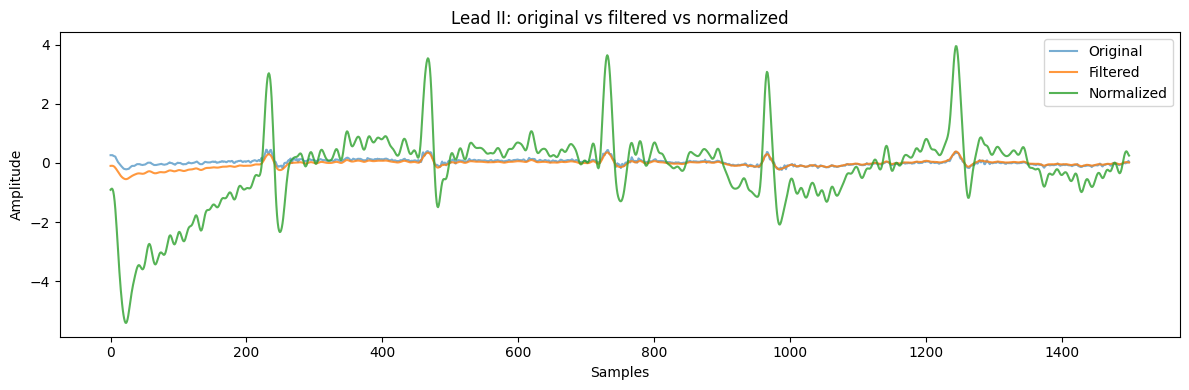

In [8]:
lead_idx = 1
samples_to_plot = int(3 * fs)

plt.figure(figsize=(12, 4))
plt.plot(signal[:samples_to_plot, lead_idx], label="Original", alpha=0.6)
plt.plot(filtered_signal[:samples_to_plot, lead_idx], label="Filtered", alpha=0.8)
plt.plot(normalized_signal[:samples_to_plot, lead_idx], label="Normalized", alpha=0.8)
plt.title(f"Lead {leads[lead_idx]}: original vs filtered vs normalized")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()
